# **<font color="red">Add Web Research to the Blog Generator</font>**

This version of the graph introduces a **research stage** that can fetch up-to-date information from the web before the blog outline is created.  
A **router node** first decides whether research is required.

If the topic needs fresh information, the pipeline performs web search and passes the evidence to the planner.

---

## **<font color="blue">Graph Workflow</font>**

#### 1. **<font color="green">START</font>**  
   Entry point of the LangGraph workflow.

#### 2. **<font color="green">router</font>**  
   The router analyzes the topic and decides:

   - Whether research is required (`needs_research`)
   - Which execution mode to use:
     - `closed_book` → no research needed  
     - `hybrid` → mix of reasoning + fresh examples  
     - `open_book` → news-style content requiring external sources
   - Generates **search queries** if research is needed.

#### 3. **<font color="green">research</font>**  
   Runs only if the router sets `needs_research = true`.

   Responsibilities:
   - Execute web searches using Tavily
   - Collect raw results
   - Normalize them into structured **EvidenceItem objects**
   - Deduplicate results by URL
   - Pass cleaned evidence to the next stage

   This ensures the planner and writers can reference **real sources** when required.

#### 4. **<font color="green">orchestrator (Planner)</font>**  
   The orchestrator generates a **structured blog plan**.

   It creates **5–9 tasks**, where each task represents a blog section and includes:
   - Section title
   - Goal
   - 3–6 actionable bullets
   - Target word count
   - Flags like:
     - `requires_code`
     - `requires_citations`
     - `requires_research`

   The orchestrator is responsible for **splitting the blog into independent sections** that can be written in parallel.

#### 5. **<font color="green">worker (Parallel Section Writers)</font>**  
   Each task from the plan triggers a **worker node**.

   Workers:
   - Receive one task
   - Write a **single blog section**
   - Follow the provided bullets in order
   - Optionally include:
     - code snippets
     - citations
     - examples

   Multiple workers run **in parallel** using LangGraph `Send()`.

#### 6. **<font color="green">reducer</font>**  
   The reducer collects outputs from all workers.

   Responsibilities:
   - Sort sections by `task.id`
   - Merge them into a single blog document
   - Generate the final Markdown
   - Save the blog to a `.md` file

#### 7. **<font color="green">END</font>**  
   The completed blog is returned from the graph execution.

---

## **<font color="blue">Final Pipeline</font>**
```
START
  ↓
router
  ↓
(research if needed)
  ↓
orchestrator
  ↓
parallel workers
  ↓
reducer
  ↓
END
```

## **<font color="blue">This architecture enables:</font>**

- Automatic research
- Parallel content generation
- Structured blog planning
- Deterministic section ordering
- Automated Markdown blog generation

In [1]:
from __future__ import annotations

import re
import operator
from typing import TypedDict, List, Annotated, Literal, Optional
from pydantic import BaseModel, Field
from pathlib import Path

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage
# from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_tavily import TavilySearch
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())


True

In [2]:
#------------------------------
# Schemas
#------------------------------

class Task(BaseModel):
    id: int
    title: str
    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section."
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=5,
        description="3-6 concrete, non-overlapping subpoints to cover in this section."
    )
    target_words: int = Field(
        ...,
        description="Target word count for this section (120-450)."
    )
    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False


class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task] = Field(default_factory=list)


class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None
    snippet: Optional[str] = None
    source: Optional[str] = None


class RouterDecision(BaseModel):
    needs_research: bool = False
    mode: Literal["closed_book", "hybrid", "open_book"] = "closed_book"
    queries: List[str] = Field(default_factory=list)


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)


In [3]:
#------------------------------
# State
#------------------------------

class State(TypedDict):
    topic: str

    # routing / research
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]

    # workers
    sections: Annotated[List[tuple[int, str]], operator.add]
    final: str


In [4]:
#------------------------------
# LLM
#------------------------------

blog_llm = ChatOllama(model="llama3.2:3b", temperature=0.5)

decision_llm = ChatOllama(model="llama3.2:3b", temperature=0.7)


In [5]:
#------------------------------
# Router
#------------------------------

ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topic where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", ranking, pricing, policy/regulation.

If needs_research=true:
- Output 3-10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""

def router_node(state: State) -> dict:
    topic = state["topic"]
    decider = decision_llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}"),
        ]
    )

    needs_research = decision.needs_research or bool(decision.queries)

    return {
        "needs_research": needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
    }


def route_next(state: State) -> str:
    return "research" if state["needs_research"] else "orchestrator"


In [6]:
#------------------------------
# Research
#------------------------------

def _tavily_search(query: str, max_results: int = 5) -> List[dict]:
    # tool = TavilySearchResults(max_results=max_results)
    tool = TavilySearch(max_results=max_results)
    response = tool.invoke({"query": query})

    # langchain_tavily.TavilySearch returns a dict: {"query": ..., "results": [...]}
    # whereas the old TavilySearchResults returned a plain list.
    # Extract the "results" list; fall back gracefully if the shape is unexpected.
    if isinstance(response, dict):
        results = response.get("results") or []
    elif isinstance(response, list):
        results = response  # legacy / alternative wrapper — keep working
    else:
        results = []

    normalized: List[dict] = []
    for r in results or []:
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )
    return normalized


RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""

def research_node(state: State) -> dict:
    queries = (state.get("queries", []) or [])
    max_results = 6

    raw_results: List[dict] = []
    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    extractor = blog_llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content=f"Raw results:\n{raw_results}"),
        ]
    )

    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e

    return {"evidence": list(dedup.values())}



In [7]:
#------------------------------
# Orchestrator
#------------------------------

ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5-9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3-6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120-550)
- You MUST populate the tasks array. An empty tasks list is invalid.

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance / cost considerations
  * security / privacy considerations (if relevant)
  * debugging / observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book:
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient sources".

Example of a valid filled output (use this structure, NOT these exact values):
{
  "blog_title": "Understanding Gradient Descent",
  "audience": "developers",
  "tone": "informative",
  "blog_kind": "explainer",
  "constraints": [],
  "tasks": [
    {
      "id": 1,
      "title": "What is Gradient Descent",
      "goal": "Explain what gradient descent is and why it matters for training ML models.",
      "bullets": [
        "Define the loss surface and what it means to minimize it",
        "Explain the role of the gradient as a direction of steepest ascent",
        "Describe the update rule: theta = theta - lr * grad"
      ],
      "target_words": 200,
      "tags": ["fundamentals"],
      "requires_research": false,
      "requires_citations": false,
      "requires_code": false
    },
    {
      "id": 2,
      "title": "Implementing Gradient Descent in Python",
      "goal": "Show a minimal working implementation of gradient descent from scratch.",
      "bullets": [
        "Define a simple quadratic loss function",
        "Implement the gradient update loop",
        "Plot the loss curve to verify convergence"
      ],
      "target_words": 300,
      "tags": ["code"],
      "requires_research": false,
      "requires_citations": false,
      "requires_code": true
    }
  ]
}

Output must strictly match the Plan schema.
"""

def orchestrator_node(state: State) -> dict:
    """Planner — generates a structured blog outline."""
    planner = blog_llm.with_structured_output(Plan)

    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")

    messages = [
        SystemMessage(content=ORCH_SYSTEM),
        HumanMessage(
            content=(
                f"Topic: {state['topic']}\n"
                f"Mode: {mode}\n\n"
                f"Evidence (ONLY use for fresh claims; may be empty):\n"
                f"{[e.model_dump() for e in evidence][:16]}"
            )
        ),
    ]

    plan = None
    for attempt in range(3):
        plan = planner.invoke(messages)
        if plan.tasks:
            break
        # Escalate on subsequent retries
        messages = [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n\n"
                    f"IMPORTANT: You returned an empty tasks list. This is invalid.\n"
                    f"You MUST include at least 5 task objects in the tasks array.\n"
                    f"Follow the example in the system prompt exactly.\n\n"
                    f"Evidence (ONLY use for fresh claims; may be empty):\n"
                    f"{[e.model_dump() for e in evidence][:16]}"
                )
            ),
        ]

    return {"plan": plan}


In [8]:
#------------------------------
# Sub-worker dispatcher
#------------------------------

def sub_worker(state: State):
    if not state.get("plan") or not state["plan"].tasks:
        raise ValueError(
            "Orchestrator produced no tasks after all retries. "
            "Cannot generate blog sections. Try a more capable model."
        )

    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])]
            },
        )
        for task in state["plan"].tasks
    ]



In [9]:
#------------------------------
# Worker
#------------------------------

WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (±15%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard:
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book:
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is
    supported by a provided Evidence URL.
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citations == true:
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning is OK without citations unless requires_citations is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented.
"""


def worker_node(payload: dict) -> dict:
    """Writes one blog section in parallel with other workers."""
    task = Task(**payload["task"])
    plan = Plan(**payload["plan"])
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]
    topic = payload["topic"]
    mode = payload.get("mode", "closed_book")

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )

    section_md = blog_llm.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
                )
            )
        ],
    ).content.strip()

    return {"sections": [(task.id, section_md)]}



In [10]:
#------------------------------
# Reducer
#------------------------------

def reducer_node(state: State) -> dict:
    """Stitches all worker sections into the final markdown blog post."""
    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    final_md = f"# {plan.blog_title}\n\n{body}\n"

    output_dir = Path("output")
    output_dir.mkdir(parents=True, exist_ok=True)

    safe_title = re.sub(r"[^\w\s-]", "_", plan.blog_title).strip()
    filename = output_dir / f"{safe_title}.md"
    filename.write_text(final_md, encoding="utf-8")

    return {"final": final_md}



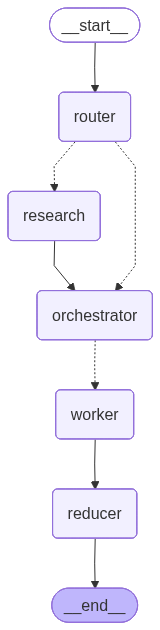

In [11]:
#------------------------------
# Graph
#------------------------------

g = StateGraph(State)

g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")
g.add_conditional_edges("orchestrator", sub_worker, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [12]:
#------------------------------
# Runner
#------------------------------

def run(topic: str):
    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "final": "",
        }
    )
    return out




In [13]:
query = "Write a blog on Social Media"
run(query)


{'topic': 'Write a blog on Social Media',
 'mode': 'hybrid',
 'needs_research': True,
 'queries': ['How do social media algorithms work?',
  'What are the most effective types of content for Instagram?',
  'Can social media be used for customer service?'],
 'evidence': [],
 'plan': Plan(blog_title='Mastering Social Media: A Guide to Building and Growing Your Online Presence', audience='developers and online marketers', tone='informative and actionable', blog_kind='explainer', constraints=[], tasks=[Task(id=1, title='Understanding Social Media Platforms', goal='Explain the key features and differences of popular social media platforms, including Facebook, Twitter, Instagram, LinkedIn, and YouTube.', bullets=["Describe the algorithm used by each platform to rank posts in users' feeds", 'Compare the character limits and posting styles for each platform', 'Highlight the unique features and use cases for each platform (e.g. IGTV for video content)'], target_words=250, tags=['fundamentals', 

In [14]:
# 58:30

In [15]:
# from langchain_community.tools import DuckDuckGoSearchRun

# ## Tool
# search_tool = DuckDuckGoSearchRun(region="us-en")

# result = search_tool.invoke({"query": "ChatGPT version released and updates from 2022 to 2026"})
# result

In [16]:
# from langchain_community.tools.tavily_search import TavilySearchResults
# from dotenv import load_dotenv, find_dotenv

# load_dotenv(find_dotenv())

# ## Tool
# search_tool = TavilySearchResults(max_results=2)
# result = search_tool.invoke({"query": "ChatGPT version released and updates from 2022 to 2026"})
# result


In [17]:
# # Oct 1927
# 1. Copenhagen Interpretation
# 1.1. Intinsic Indeterminism (Then subatomic world is inherently random)
# 1.2. Quantum Runs on Probability
# 1.3. Partical and Wave Depends on Experiment

# # Quantum Entanglement
# Electrons (Spin) Up Spin, Down Spin
# "Spooky action at a distance"

# # Bell Equation (Bell's Inequality) & Experiment
# 1. Color: RED | Blue
# 2. Size: Big | Small
# 3. Shine: Shiny | Dull

# Group:
# 1. Color != Size : Different Color & Different Size But Shine could be same
# 2. Size != Shine : Different Size & Different Shine But Color could be same
# 3. Color != Shine : Different Color & Different Shine But Size could be same

# # Quantum Computing
# # Quantum Cryptography
